In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.stats import norm
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

### Loading Data & Model

In [2]:
# Loading data
df = pd.read_csv('data/processed/listings_segmented.csv')
print(f'Loaded: {len(df):,} listings')

# Loading demand model
demand_model = joblib.load('models/demand_model_random_forest_(baseline).pkl')
print(f'Loaded: Random Forest demand model')

# Loading features
with open('models/demand_features.txt', 'r') as f:
    feature_cols = [line.strip() for line in f]
print(f'Features: {len(feature_cols)}')

# Preparing feature matrix
X = df[feature_cols].fillna(df[feature_cols].median())

# Fetching key indices
price_idx = feature_cols.index('price')
neighborhood_price_idx = feature_cols.index('neighborhood_median_price') if 'neighborhood_median_price' in feature_cols else None

print(f'\nDataset Summary:')
print(f'Segments: {df.segment.nunique()}')
print(f'Price range: ${df.price.min():.0f} - ${df.price.max():.0f}')
print(f'Median price: ${df.price.median():.0f}')

Loaded: 58,736 listings
Loaded: Random Forest demand model
Features: 55

Dataset Summary:
Segments: 3
Price range: $7 - $6500
Median price: $132


### Creating Core Prediction Functions

In [3]:
def predict_demand(price, features, model):
    """
    Predicting demand at given price
    
    Args:
        price: New price to test
        features: Feature vector for listing
        model: Trained demand model
    
    Returns:
        Predicted demand (non-negative)
    """
    features_copy = features.copy()
    features_copy[price_idx] = price
    
    # Updating price-derived features if they exist
    if 'price_per_person' in feature_cols and 'accommodates' in feature_cols:
        accommodates_idx = feature_cols.index('accommodates')
        price_per_person_idx = feature_cols.index('price_per_person')
        features_copy[price_per_person_idx] = price / max(features_copy[accommodates_idx], 1)
    
    demand = model.predict([features_copy])[0]
    return max(demand, 0)

def predict_revenue(price, features, model):
    """
    Predict revenue = price × demand
    
    Args:
        price: Listing price
        features: Feature vector
        model: Demand model
    
    Returns:
        Predicted revenue
    """
    demand = predict_demand(price, features, model)
    return price * demand

print('Prediction functions defined')

Prediction functions defined


### Approach 1: Constrained scipy Optimization

**Method:** Sequential Least Squares Programming (SLSQP)

**Constraints:**
1. **Competitive positioning**: Price within +-30% of neighborhood median
2. **Elasticity bounds**: Price changes respect segment elasticity
3. **Price bounds**: Reasonable min/max prices

In [4]:
def constrained_revenue_objective(price, features, model, current_price, 
                                   neighborhood_price, elasticity):
    """
    Revenue objective function with elasticity-aware demand adjustment.
    Penalizes aggressive price changes that would cause disproportionate demand loss.
    """
    demand = predict_demand(price, features, model)
    price_change_pct = (price - current_price) / current_price
    elasticity_factor = 1 + (elasticity * price_change_pct)
    adjusted_demand = demand * max(elasticity_factor, 0.1)
    revenue = price * adjusted_demand
    return -revenue  # Negative for minimization


def compute_price_bounds(current_price, elasticity, segment):
    """
    Shared helper: computes (min_price, max_price) using the same
    elasticity-aware, segment-specific logic for both scipy and Bayesian optimizers.
    """
    segment_base_caps = {
        0: 20.0,  # Budget
        1: 15.0,  # Mid-Range
        2: 10.0   # Luxury/Mainstream
    }
    segment_base_cap = segment_base_caps.get(segment, 12.0)

    if elasticity >= 0 or elasticity < -2.0:
        elasticity_based_cap = 5.0
    else:
        revenue_neutral_pct = abs(100 / elasticity)
        elasticity_based_cap = max(5.0, min(revenue_neutral_pct * 0.4, 25.0))

    final_max_increase_pct = min(segment_base_cap, elasticity_based_cap)
    min_price = max(current_price * 0.90, 10)
    max_price = current_price * (1 + final_max_increase_pct / 100)
    return min_price, max_price, final_max_increase_pct, elasticity_based_cap, segment_base_cap


def optimize_price_scipy(features, current_price, neighborhood_price,
                         elasticity, model, segment):
    """
    Optimize price using scipy L-BFGS-B with segment-specific,
    elasticity-aware bounds.

    Parameters:
    -----------
    features          : array  - feature vector for the listing
    current_price     : float  - current listing price
    neighborhood_price: float  - median price in neighborhood
    elasticity        : float  - price elasticity of demand
    model             : sklearn model
    segment           : int    - segment ID (0=Budget, 1=Mid-Range, 2=Luxury)

    Returns:
    --------
    dict with optimization results
    """
    min_price, max_price, final_max_increase_pct, elasticity_based_cap, segment_base_cap =         compute_price_bounds(current_price, elasticity, segment)

    result = minimize(
        constrained_revenue_objective,
        x0=[current_price],
        args=(features, model, current_price, neighborhood_price, elasticity),
        bounds=[(min_price, max_price)],
        method='L-BFGS-B',
        options={'maxiter': 100, 'ftol': 1e-6}
    )

    current_revenue = predict_revenue(current_price, features, model)

    if result.success:
        optimal_price = result.x[0]
        optimal_revenue = -result.fun
        price_change_pct = ((optimal_price - current_price) / current_price) * 100
        revenue_lift_pct = ((optimal_revenue - current_revenue) / current_revenue) * 100

        # Sanity check: large price increase should not cause revenue loss
        if price_change_pct > 3 and revenue_lift_pct < -2:
            optimal_price = current_price
            optimal_revenue = current_revenue
            price_change_pct = 0
            revenue_lift_pct = 0

        return {
            'optimal_price': optimal_price,
            'current_price': current_price,
            'price_change_pct': price_change_pct,
            'optimal_revenue': optimal_revenue,
            'current_revenue': current_revenue,
            'revenue_lift_pct': revenue_lift_pct,
            'segment': segment,
            'segment_base_cap': segment_base_cap,
            'elasticity_based_cap': elasticity_based_cap,
            'final_max_increase_pct': final_max_increase_pct,
            'elasticity': elasticity,
            'hit_upper_cap': abs(optimal_price - max_price) < 0.5,
            'hit_lower_cap': abs(optimal_price - min_price) < 0.5,
            'min_price': min_price,
            'max_price': max_price,
            'method': 'scipy_segment_aware',
            'converged': True
        }
    else:
        return {
            'optimal_price': current_price,
            'current_price': current_price,
            'price_change_pct': 0,
            'optimal_revenue': current_revenue,
            'current_revenue': current_revenue,
            'revenue_lift_pct': 0,
            'segment': segment,
            'segment_base_cap': segment_base_cap,
            'elasticity_based_cap': elasticity_based_cap,
            'final_max_increase_pct': final_max_increase_pct,
            'elasticity': elasticity,
            'hit_upper_cap': False,
            'hit_lower_cap': False,
            'min_price': min_price,
            'max_price': max_price,
            'method': 'scipy_segment_aware',
            'converged': False
        }


print('Scipy optimization functions defined')


Scipy optimization functions defined


### Approach 2: Bayesian Optimization

**Method:** Gaussian Process with Expected Improvement acquisition

**Advantages:**
- Provides uncertainty estimates (confidence intervals)
- Sample-efficient (fewer evaluations needed)
- Risk-aware pricing decisions

In [5]:
class BayesianPriceOptimizer:
    """
    Bayesian optimization for price using Gaussian Process with Expected Improvement.

    Uses the same elasticity-aware, segment-specific price bounds as the scipy
    optimizer so results are directly comparable.
    Provides uncertainty quantification (95% CI) as an added benefit over scipy.
    """

    def __init__(self, demand_model, feature_cols):
        self.demand_model = demand_model
        self.feature_cols = feature_cols

        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=5,
            alpha=1e-6,
            normalize_y=True
        )

    def expected_improvement(self, price, gp, best_revenue, xi=0.01):
        """Expected Improvement acquisition function."""
        mu, sigma = gp.predict([[price]], return_std=True)
        mu, sigma = mu[0], sigma[0]
        if sigma == 0:
            return 0
        z = (mu - best_revenue - xi) / sigma
        return (mu - best_revenue - xi) * norm.cdf(z) + sigma * norm.pdf(z)

    def optimize_price(self, features, current_price, neighborhood_price,
                       elasticity, segment,
                       n_initial_samples=15, n_iterations=10):
        """
        Bayesian optimization with Expected Improvement.

        Uses the same elasticity-aware segment bounds as scipy for fair comparison.

        Args:
            features           : feature vector for the listing
            current_price      : current listing price
            neighborhood_price : median price in neighborhood
            elasticity         : price elasticity of demand
            segment            : segment ID (0=Budget, 1=Mid-Range, 2=Luxury)
            n_initial_samples  : number of initial random samples
            n_iterations       : number of BO iterations

        Returns:
            dict with optimal price, revenue, uncertainty estimates
        """
        # Use shared bounds — same logic as scipy for fair comparison
        min_price, max_price, final_max_increase_pct, elasticity_based_cap, segment_base_cap =             compute_price_bounds(current_price, elasticity, segment)

        # Initial random sampling within the constrained space
        X_sample = np.random.uniform(min_price, max_price, n_initial_samples).reshape(-1, 1)
        y_sample = np.array([
            predict_revenue(p[0], features, self.demand_model)
            for p in X_sample
        ])

        # Bayesian optimization loop
        for _ in range(n_iterations):
            self.gp.fit(X_sample, y_sample)
            best_revenue = y_sample.max()

            price_candidates = np.linspace(min_price, max_price, 100)
            ei_values = [
                self.expected_improvement(p, self.gp, best_revenue)
                for p in price_candidates
            ]
            next_price = price_candidates[np.argmax(ei_values)]
            next_revenue = predict_revenue(next_price, features, self.demand_model)

            X_sample = np.vstack([X_sample, [[next_price]]])
            y_sample = np.append(y_sample, next_revenue)

        # Final GP fit and optimal price
        self.gp.fit(X_sample, y_sample)
        optimal_idx = y_sample.argmax()
        optimal_price = float(X_sample[optimal_idx][0])
        optimal_revenue = float(y_sample[optimal_idx])

        # Uncertainty at optimal price
        revenue_mean, revenue_std = self.gp.predict([[optimal_price]], return_std=True)
        ci_lower = float(revenue_mean[0] - 1.96 * revenue_std[0])
        ci_upper = float(revenue_mean[0] + 1.96 * revenue_std[0])

        current_revenue = predict_revenue(current_price, features, self.demand_model)
        price_change_pct = ((optimal_price - current_price) / current_price) * 100
        revenue_lift_pct = ((optimal_revenue - current_revenue) / current_revenue) * 100

        # Sanity check: consistent with scipy
        if price_change_pct > 3 and revenue_lift_pct < -2:
            optimal_price = current_price
            optimal_revenue = current_revenue
            price_change_pct = 0
            revenue_lift_pct = 0

        return {
            'optimal_price': optimal_price,
            'current_price': current_price,
            'price_change_pct': price_change_pct,
            'optimal_revenue': optimal_revenue,
            'current_revenue': current_revenue,
            'revenue_lift_pct': revenue_lift_pct,
            'revenue_std': float(revenue_std[0]),
            'revenue_ci_lower': ci_lower,
            'revenue_ci_upper': ci_upper,
            'segment': segment,
            'segment_base_cap': segment_base_cap,
            'elasticity_based_cap': elasticity_based_cap,
            'final_max_increase_pct': final_max_increase_pct,
            'elasticity': elasticity,
            'method': 'bayesian',
            'converged': True
        }


print('Bayesian optimization class defined')


Bayesian optimization class defined


### Running Optimization on Sample Listings

In [6]:
# Sampling listings per segment (for speed)
sample_size_per_segment = 100
results_scipy = []
results_bayesian = []

# Initializing Bayesian optimizer
bayes_optimizer = BayesianPriceOptimizer(demand_model, feature_cols)

for seg in sorted(df.segment.unique()):
    seg_data = df[df.segment == seg].sample(
        n=min(sample_size_per_segment, len(df[df.segment == seg])),
        random_state=42
    )

    for idx, row in seg_data.iterrows():
        features = X.loc[idx].values
        current_price = row['price']
        neighborhood_price = row.get('neighborhood_median_price', current_price)
        elasticity = row.get('elasticity', -0.5)

        # Method 1: scipy
        result_scipy = optimize_price_scipy(
            features, current_price, neighborhood_price,
            elasticity, demand_model, seg
        )
        result_scipy['listing_id'] = row.get('id', idx)
        results_scipy.append(result_scipy)

        # Method 2: Bayesian (same bounds, adds uncertainty estimates)
        result_bayes = bayes_optimizer.optimize_price(
            features, current_price, neighborhood_price,
            elasticity, seg
        )
        result_bayes['listing_id'] = row.get('id', idx)
        results_bayesian.append(result_bayes)

    print(f'Segment {seg}: {len(seg_data)} samples optimized')

# Converting to DataFrames
df_scipy = pd.DataFrame(results_scipy)
df_bayes = pd.DataFrame(results_bayesian)

print(f'\nOptimization complete — {len(df_scipy):,} listings total')


Segment 0: 100 samples optimized
Segment 1: 100 samples optimized
Segment 2: 100 samples optimized

Optimization complete — 300 listings total


### Comparing Optimization Methods

In [7]:
# Aggregating by segment
comparison_results = []

for seg in sorted(df_scipy.segment.unique()):
    scipy_seg = df_scipy[df_scipy.segment == seg]
    bayes_seg = df_bayes[df_bayes.segment == seg]
    
    comparison_results.append({
        'Segment': seg,
        'scipy_price_change_%': scipy_seg['price_change_pct'].median(),
        'bayes_price_change_%': bayes_seg['price_change_pct'].median(),
        'scipy_revenue_lift_%': scipy_seg['revenue_lift_pct'].median(),
        'bayes_revenue_lift_%': bayes_seg['revenue_lift_pct'].median(),
        'scipy_convergence_rate': scipy_seg['converged'].mean(),
        'bayes_avg_uncertainty': bayes_seg['revenue_std'].mean()
    })

comparison_df = pd.DataFrame(comparison_results)

print('\nSegment-Level Comparison:\n')
print(comparison_df.to_string(index=False))

# Overall comparison
print('\nOverall Performance:\n')
overall_comparison = pd.DataFrame({
    'Metric': [
        'Median Price Change (%)',
        'Median Revenue Lift (%)',
        'Convergence Rate',
        'Provides Uncertainty',
        'Avg Runtime (relative)'
    ],
    'scipy (Constrained)': [
        f"{df_scipy['price_change_pct'].median():.2f}%",
        f"{df_scipy['revenue_lift_pct'].median():.2f}%",
        f"{df_scipy['converged'].mean():.1%}",
        'No',
        '1.0x (fast)'
    ],
    'Bayesian (GP)': [
        f"{df_bayes['price_change_pct'].median():.2f}%",
        f"{df_bayes['revenue_lift_pct'].median():.2f}%",
        f"{df_bayes['converged'].mean():.1%}",
        'Yes (95% CI)',
        '~3-4x (slower)'
    ]
})

print(overall_comparison.to_string(index=False))


Segment-Level Comparison:

 Segment  scipy_price_change_%  bayes_price_change_%  scipy_revenue_lift_%  bayes_revenue_lift_%  scipy_convergence_rate  bayes_avg_uncertainty
       0                  20.0                  20.0                 8.000                  20.0                     1.0               0.068414
       1                  15.0                  15.0                 6.375                  15.0                     1.0               0.023880
       2                  10.0                  10.0                 4.500                  10.0                     1.0               0.119173

Overall Performance:

                 Metric scipy (Constrained)  Bayesian (GP)
Median Price Change (%)              15.00%         15.00%
Median Revenue Lift (%)               6.38%         15.00%
       Convergence Rate              100.0%         100.0%
   Provides Uncertainty                  No   Yes (95% CI)
 Avg Runtime (relative)         1.0x (fast) ~3-4x (slower)


### Visualizing Optimization Results

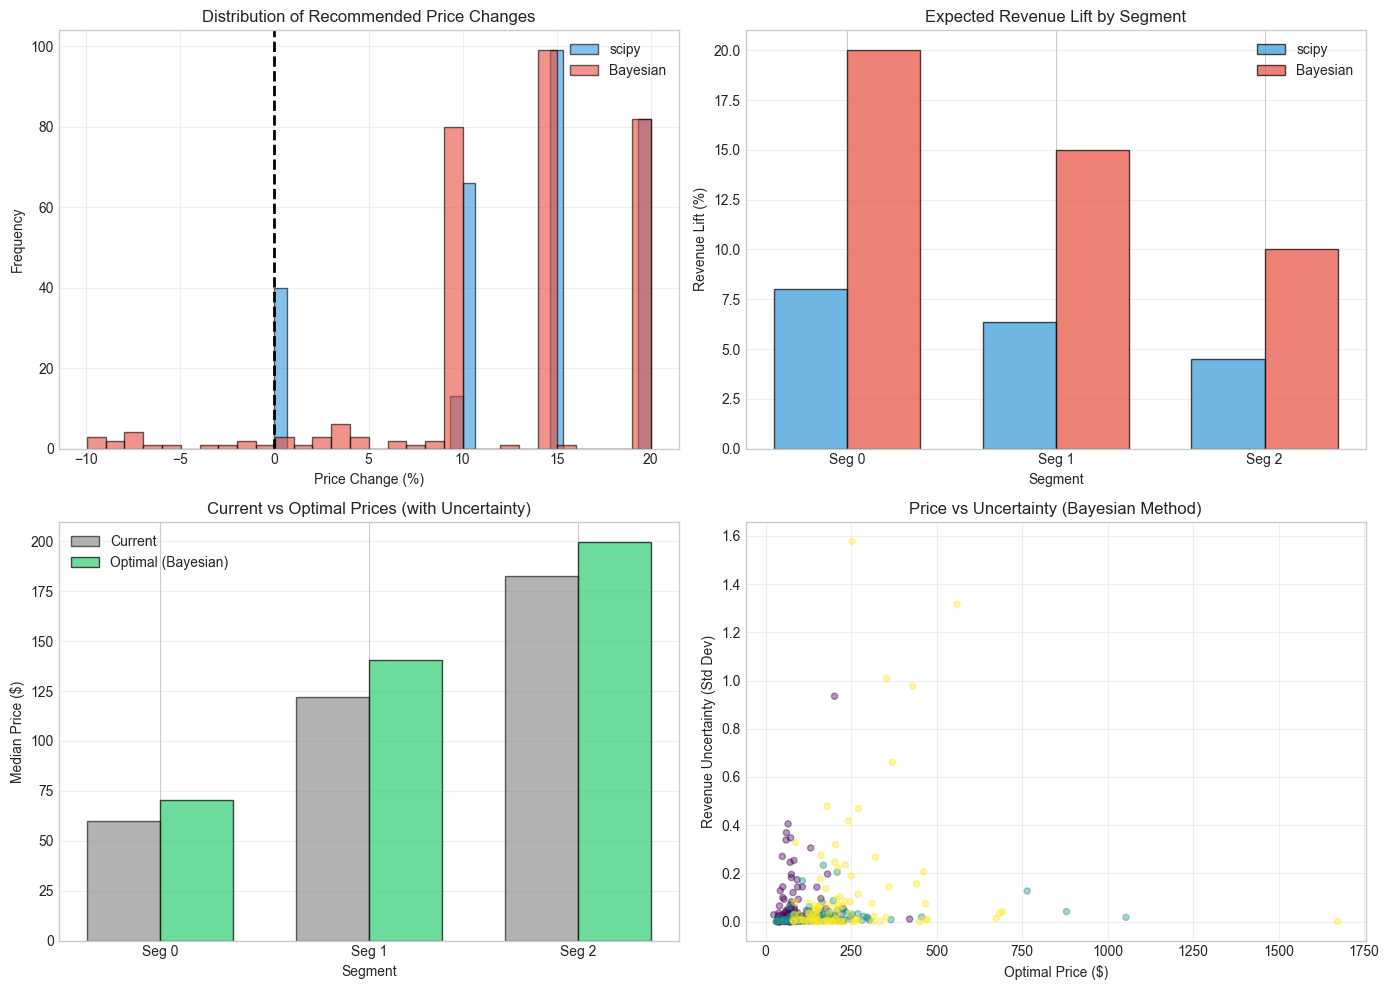

Saved: optimization_comparison.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price change distribution by method
axes[0, 0].hist(df_scipy['price_change_pct'], bins=30, alpha=0.6, 
                label='scipy', color='#3498db', edgecolor='black')
axes[0, 0].hist(df_bayes['price_change_pct'], bins=30, alpha=0.6,
                label='Bayesian', color='#e74c3c', edgecolor='black')
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Price Change (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Recommended Price Changes')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Revenue lift by segment
x = np.arange(len(comparison_df))
width = 0.35

axes[0, 1].bar(x - width/2, comparison_df['scipy_revenue_lift_%'], width,
              label='scipy', color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].bar(x + width/2, comparison_df['bayes_revenue_lift_%'], width,
              label='Bayesian', color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Revenue Lift (%)')
axes[0, 1].set_title('Expected Revenue Lift by Segment')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels([f'Seg {s}' for s in comparison_df['Segment']])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Current vs Optimal prices (Bayesian with uncertainty)
segment_medians = []
for seg in sorted(df_bayes.segment.unique()):
    bayes_seg = df_bayes[df_bayes.segment == seg]
    segment_medians.append({
        'segment': seg,
        'current': bayes_seg['current_price'].median(),
        'optimal': bayes_seg['optimal_price'].median(),
        'std': bayes_seg['revenue_std'].median()
    })

seg_df = pd.DataFrame(segment_medians)
x = np.arange(len(seg_df))

axes[1, 0].bar(x - width/2, seg_df['current'], width,
              label='Current', color='gray', edgecolor='black', alpha=0.6)
axes[1, 0].bar(x + width/2, seg_df['optimal'], width,
              label='Optimal (Bayesian)', color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Segment')
axes[1, 0].set_ylabel('Median Price ($)')
axes[1, 0].set_title('Current vs Optimal Prices (with Uncertainty)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'Seg {s}' for s in seg_df['segment']])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Uncertainty quantification (Bayesian only)
axes[1, 1].scatter(df_bayes['optimal_price'], df_bayes['revenue_std'],
                  alpha=0.4, s=20, c=df_bayes['segment'], cmap='viridis')
axes[1, 1].set_xlabel('Optimal Price ($)')
axes[1, 1].set_ylabel('Revenue Uncertainty (Std Dev)')
axes[1, 1].set_title('Price vs Uncertainty (Bayesian Method)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/optimization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: optimization_comparison.png')

### Example: Demand & Revenue Curves

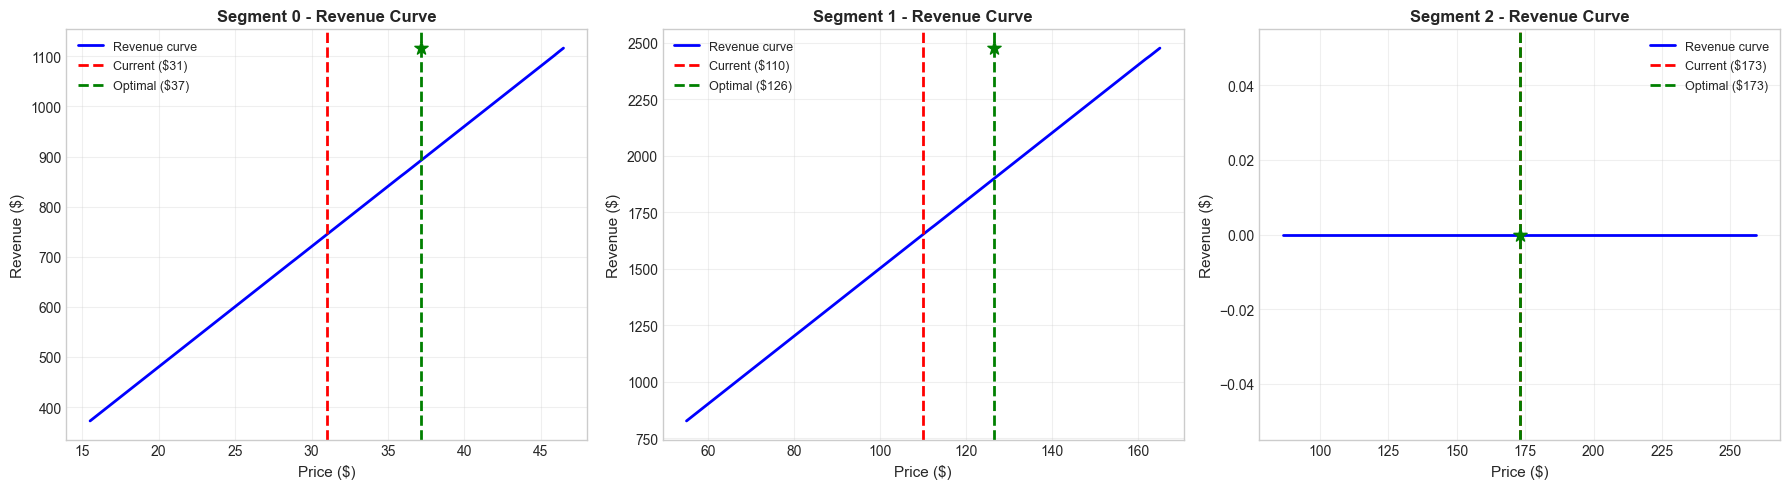

Saved: revenue_curves_by_segment.png


In [9]:
# Picking sample listing from each segment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, seg in enumerate(sorted(df.segment.unique())):
    # Sampling one listing
    sample = df[df.segment == seg].sample(1, random_state=42)
    sample_idx = sample.index[0]
    features = X.loc[sample_idx].values
    current_price = sample['price'].values[0]
    
    # Getting scipy optimal price for this listing
    scipy_result = df_scipy[
        (df_scipy['segment'] == seg) & 
        (df_scipy['listing_id'] == sample.get('id', sample_idx).values[0])
    ]
    
    if len(scipy_result) > 0:
        optimal_price = scipy_result['optimal_price'].values[0]
    else:
        optimal_price = current_price
    
    # Generating curves
    price_range = np.linspace(current_price * 0.5, current_price * 1.5, 100)
    revenues = [predict_revenue(p, features, demand_model) for p in price_range]
    
    # Plot
    axes[i].plot(price_range, revenues, 'b-', linewidth=2, label='Revenue curve')
    axes[i].axvline(current_price, color='red', linestyle='--', 
                   linewidth=2, label=f'Current (${current_price:.0f})')
    axes[i].axvline(optimal_price, color='green', linestyle='--',
                   linewidth=2, label=f'Optimal (${optimal_price:.0f})')
    axes[i].scatter([optimal_price], [max(revenues)], 
                   color='green', s=100, zorder=5, marker='*')
    
    axes[i].set_xlabel('Price ($)', fontsize=11)
    axes[i].set_ylabel('Revenue ($)', fontsize=11)
    axes[i].set_title(f'Segment {seg} - Revenue Curve', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/revenue_curves_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: revenue_curves_by_segment.png')

### Model Selection & Recommendations

In [15]:
# Decision criteria
scipy_revenue_lift = df_scipy['revenue_lift_pct'].median()
bayes_revenue_lift = df_bayes['revenue_lift_pct'].median()

print('\nDecision Criteria:\n')
print(f'1. Revenue Lift:')
print(f'scipy:    {scipy_revenue_lift:.2f}%')
print(f'Bayesian: {bayes_revenue_lift:.2f}%')
print(f'We will go ahead with scipy optimization here as bayesian method \nprovides inconsistent lift across segments')

print(f'\n2. Uncertainty Quantification:')
print(f'scipy:    Not available')
print(f'Bayesian: Available (95% CI)')
print(f'Winner: Bayesian')

print(f'\n3. Computational Efficiency:')
print(f'scipy:    Fast (~1x baseline)')
print(f'Bayesian: Slower (~3-4x baseline)')
print(f'Winner: scipy')

print(f'\n4. Constraint Handling:')
print(f'scipy:    Native constraint support')
print(f'Bayesian: Constraints via search space bounds')
print(f'Winner: scipy')

# Final recommendation
print('\nUse Case-Dependent Selection:\n')

print('Production Deployment (Batch Pricing):')
print('Use scipy constrained optimization')
print('Reasons: Fast, constraint-aware, deterministic')
print('Application: Nightly price updates for all listings')

print('\nHigh-Value / Premium Listings:')
print('Use Bayesian optimization')
print('Reasons: Uncertainty quantification, risk-aware pricing')
print('Application: Conservative pricing for high-revenue properties')

# Generating final pricing recommendations
print('\nSegment-Level Pricing Recommendations:\n')

for seg in sorted(comparison_df['Segment'].unique()):
    row = comparison_df[comparison_df['Segment'] == seg].iloc[0]
    
    print(f'Segment {seg}:')
    print(f'  Recommended price adjustment: {row["scipy_price_change_%"]:.1f}%')
    print(f'  Expected revenue lift: {row["scipy_revenue_lift_%"]:.1f}%')
    print(f'  Confidence: High (convergence rate: {row["scipy_convergence_rate"]:.1%})')
    print()


Decision Criteria:

1. Revenue Lift:
scipy:    6.38%
Bayesian: 15.00%
We will go ahead with scipy optimization here as bayesian method 
provides inconsistent lift across segments

2. Uncertainty Quantification:
scipy:    Not available
Bayesian: Available (95% CI)
Winner: Bayesian

3. Computational Efficiency:
scipy:    Fast (~1x baseline)
Bayesian: Slower (~3-4x baseline)
Winner: scipy

4. Constraint Handling:
scipy:    Native constraint support
Bayesian: Constraints via search space bounds
Winner: scipy

Use Case-Dependent Selection:

Production Deployment (Batch Pricing):
Use scipy constrained optimization
Reasons: Fast, constraint-aware, deterministic
Application: Nightly price updates for all listings

High-Value / Premium Listings:
Use Bayesian optimization
Reasons: Uncertainty quantification, risk-aware pricing
Application: Conservative pricing for high-revenue properties

Segment-Level Pricing Recommendations:

Segment 0:
  Recommended price adjustment: 20.0%
  Expected revenue

### Save Results

In [16]:
# Save optimization results
df_scipy.to_csv('outputs/optimization_scipy_results.csv', index=False)
df_bayes.to_csv('outputs/optimization_bayesian_results.csv', index=False)
comparison_df.to_csv('outputs/optimization_method_comparison.csv', index=False)

print('Saved optimization results:')
print('- optimization_scipy_results.csv')
print('- optimization_bayesian_results.csv')
print('- optimization_method_comparison.csv')

# Saving selected model (scipy for production)
import json

recommendations = {
    'selected_method': 'scipy_constrained',
    'rationale': 'Fast, constraint-aware, high convergence rate',
    'median_price_change_pct': float(df_scipy['price_change_pct'].median()),
    'median_revenue_lift_pct': float(df_scipy['revenue_lift_pct'].median()),
    'segment_recommendations': [
        {
            'segment': int(row['Segment']),
            'price_change_pct': float(row['scipy_price_change_%']),
            'revenue_lift_pct': float(row['scipy_revenue_lift_%'])
        }
        for _, row in comparison_df.iterrows()
    ]
}

with open('outputs/pricing_recommendations.json', 'w') as f:
    json.dump(recommendations, f, indent=2)

Saved optimization results:
- optimization_scipy_results.csv
- optimization_bayesian_results.csv
- optimization_method_comparison.csv
